# Breast Cancer Survival Classification

## Project Overview

This project uses a breast cancer patient dataset containing demographic, clinical, and tumor-related information. The dataset includes features such as age, tumor stage, tumor size, hormone receptor status, and lymph node involvement.

## Project Goal

The objective of this project is to build a machine learning classification model capable of predicting a patient's survival status:

- Alive
- Dead

based on the available clinical and diagnostic information.

## Why Classification?

This problem is a classification task because the target variable consists of two discrete categories: Alive and Dead. The goal is to assign each patient to the correct outcome class rather than predict a continuous numerical value.

# ============================
# 1. Import Libraries
# ============================

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# 2. Load Dataset
# ============================

In [64]:
df = pd.read_csv("Breast_Cancer.csv")
df.columns = df.columns.str.strip() #removing any extra blank space from the column names before using them for plotting.

# ============================
# 3. Show Dataset Details
# ============================

In [65]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [66]:
df.shape

(4024, 16)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Reginol Node Positive   4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status                  4024 non

In [68]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


# ============================
# 4. Visualize The Dataset
# ============================

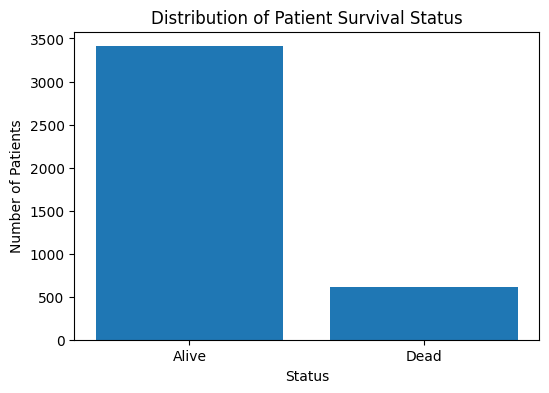

In [69]:
status_counts = df["Status"].value_counts()
# Status:
# Alive    3405
# Dead      619

plt.figure(figsize=(6, 4))
plt.bar(status_counts.index, status_counts.values)
# status_counts.index
# Index(['Alive', 'Dead'])

# status_counts.values
# array([3405, 619])

plt.title("Distribution of Patient Survival Status")
plt.xlabel("Status")
plt.ylabel("Number of Patients")

plt.show()

The target variable represents patient survival status and contains two categories: Alive and Dead. Visualizing the class distribution helps identify potential class imbalance, which may influence model training and evaluation. A significant imbalance would require greater attention to metrics such as precision, recall, and F1-score rather than relying solely on accuracy.

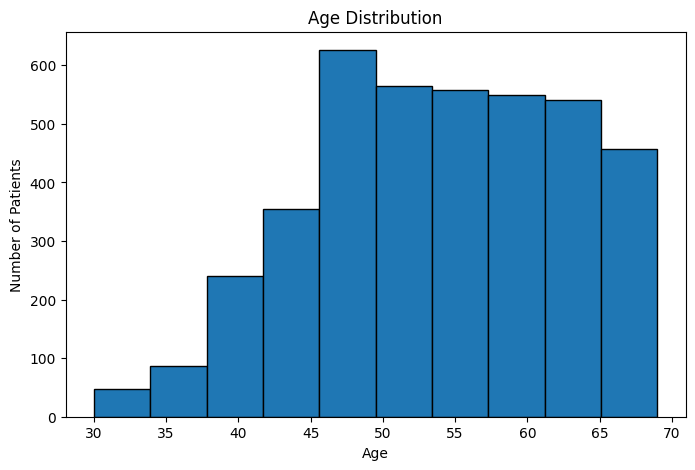

In [70]:
plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=10, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

The age distribution is concentrated among middle-aged and older patients, with most observations falling between 45 and 68 years. Younger patients are comparatively less common, resulting in a slight concentration toward higher age groups.

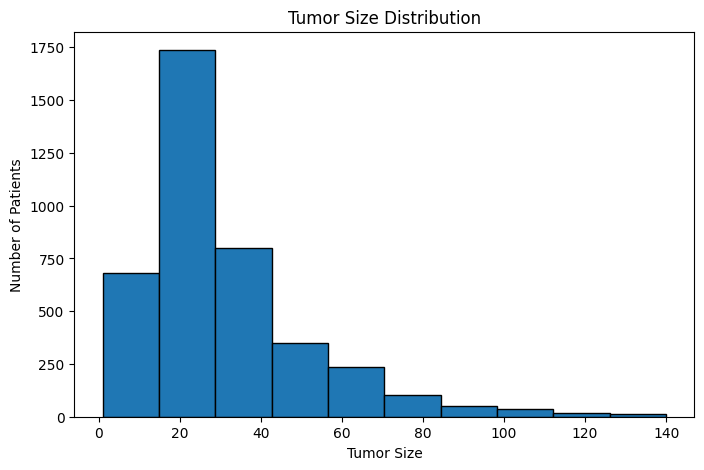

In [71]:
plt.figure(figsize=(8, 5))
plt.hist(df["Tumor Size"], bins=10, edgecolor='black')

plt.title("Tumor Size Distribution")
plt.xlabel("Tumor Size")
plt.ylabel("Number of Patients")

plt.show()

The tumor size distribution is positively skewed. Most patients have relatively small to medium tumor sizes, while a smaller number of patients exhibit substantially larger tumors. This creates a long right tail in the distribution.

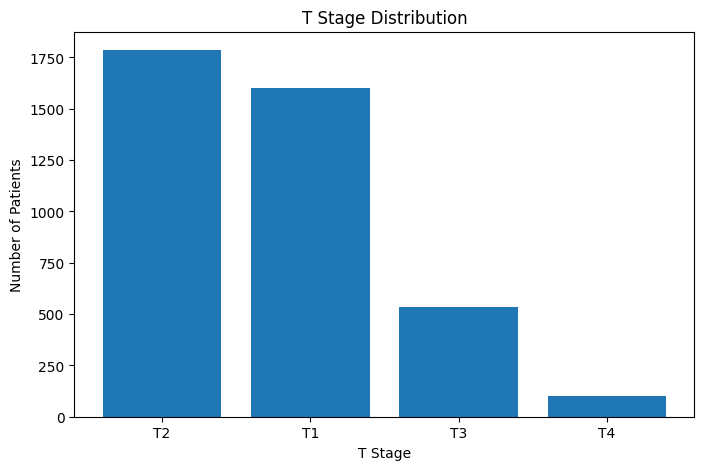

In [72]:
T_stage_counts = df["T Stage"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(T_stage_counts.index,T_stage_counts.values)
plt.title("T Stage Distribution")
plt.xlabel("T Stage")
plt.ylabel("Number of Patients")
plt.show()

T1 and T2 are the dominant tumor stages in the dataset, with T2 being the most common category. More advanced stages (T3 and T4) occur much less frequently, indicating that most patients in the dataset were diagnosed at earlier stages.

In [73]:
import seaborn as sns

<Axes: >

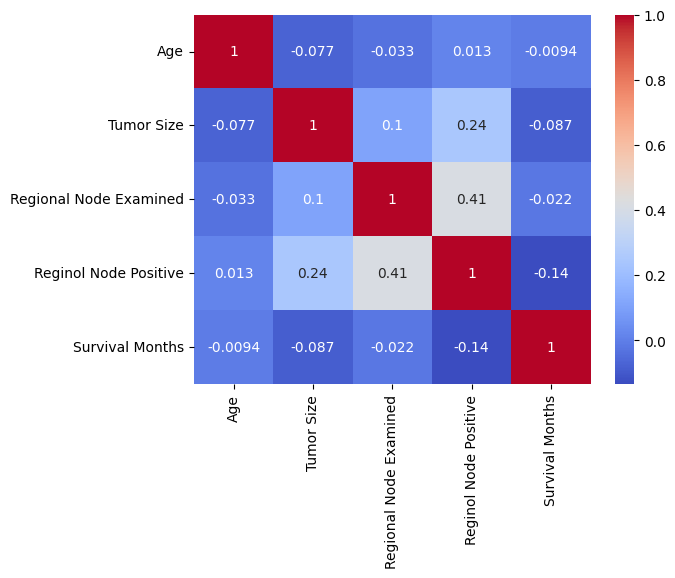

In [74]:
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")

The correlation heatmap reveals generally weak relationships between the numerical features in the dataset. The strongest positive correlation is observed between Regional Node Examined and Regional Node Positive, while Age and Survival Months show almost no linear relationship. Overall, no pair of numerical features exhibits extremely high correlation.

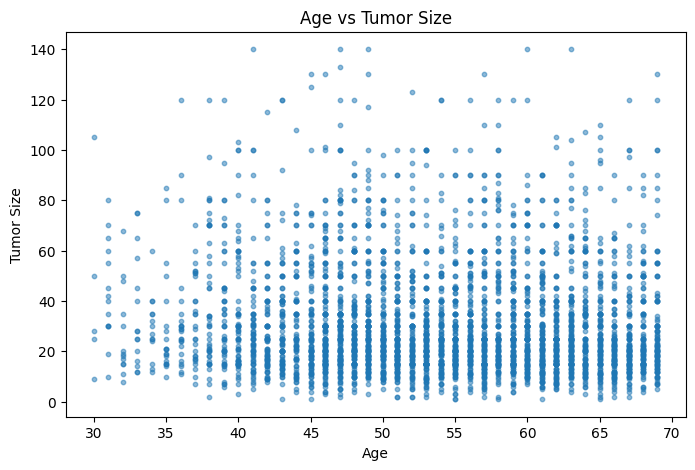

In [75]:
tumor_size_values = df["Tumor Size"].values
age_values = df["Age"].values
plt.figure(figsize=(8, 5))
plt.scatter(age_values, tumor_size_values, s=10, alpha=0.5)

plt.title("Age vs Tumor Size")
plt.xlabel("Age")
plt.ylabel("Tumor Size")

plt.show()

The scatter plot reveals no clear relationship between age and tumor size. The broad dispersion of points is consistent with the near-zero correlation observed in the correlation heatmap.

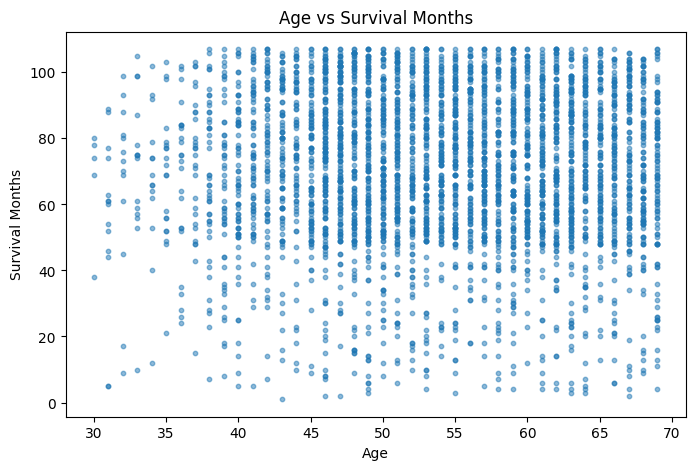

In [76]:
age_values = df["Age"].values
survival_months_values = df["Survival Months"].values
plt.figure(figsize=(8, 5))
plt.scatter(age_values, survival_months_values, s=10, alpha=0.5)

plt.title("Age vs Survival Months")
plt.xlabel("Age")
plt.ylabel("Survival Months")

plt.show()

The scatter plot shows no obvious linear relationship between age and survival months. The points are widely dispersed across all age groups, supporting the weak correlation observed in the correlation heatmap.

# ============================
# 5. Data Cleaning 
# ============================

In [77]:
missing_values = df.isnull().sum()
print(missing_values)

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64


No missing values were found in the dataset, so no further handling was required.

In [78]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
df = df.drop_duplicates()

Number of duplicate rows: 1


One duplicate record was identified and removed from the dataset.

In [79]:
X = df.drop(["Status", "Survival Months"], axis=1)

y = df["Status"]

## Feature Selection

The `Status` column was selected as the target variable because it represents the outcome that the model will learn to predict.

The `Survival Months` column was removed from the feature set because it contains information that would not be available at prediction time and may introduce data leakage. Including this feature could allow the model to indirectly infer the target rather than learn meaningful patterns from the clinical and demographic characteristics of the patients.

All remaining features were retained as potential predictors.

# ============================
# 6. Preprocessing
# ============================

In [80]:
#encoding the target labels. because Machine learning models work with numbers.
y = y.map({
    "Dead": 0,
    "Alive": 1
})

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

splitting the training and testing data in 80/20.

In [82]:
X_train.dtypes

Age                       int64
Race                        str
Marital Status              str
T Stage                     str
N Stage                     str
6th Stage                   str
differentiate               str
Grade                       str
A Stage                     str
Tumor Size                int64
Estrogen Status             str
Progesterone Status         str
Regional Node Examined    int64
Reginol Node Positive     int64
dtype: object

In [83]:
numeric_features = [
    "Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive"
]

categorical_features = [
    "Race",
    "Marital Status",
    "T Stage",
    "N Stage",
    "6th Stage",
    "differentiate",
    "Grade",
    "A Stage",
    "Estrogen Status",
    "Progesterone Status"
]

idenify each column data type and then manually define them.

In [84]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    # ("step_name", preprocessing_method, columns_to_apply_it_to)
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

The preprocessing step applies StandardScaler to numerical features and OneHotEncoder to categorical features. The transformer is fitted only on the training data to avoid data leakage, then the same learned transformations are applied to both the training and testing sets.

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(X_train_processed.shape)
print(X_test_processed.shape)